<a href="https://www.kaggle.com/code/aashishthegreat/telco-customer-churn-prediction?scriptVersionId=308107360" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## 1. Introduction

Customer churn prediction helps telecom providers identify customers likely to leave and take proactive retention actions.
This notebook analyzes the Telco Customer Churn dataset using exploratory analysis and machine learning models.
We compare baseline models and then improve performance using tuned ensemble methods (e.g., Gradient Boosting / XGBoost).

**Target:** `Churn` (Yes/No)
**Main metric:** ROC-AUC (threshold-independent, good for imbalanced classes)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# XGBoost
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

RANDOM_STATE = 42
sns.set_theme()

## 2. Dataset

We use the Telco Customer Churn dataset.
It contains customer demographics, service usage, billing information, and the churn label.

In [2]:
df = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(df.shape)
df.info()

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

## 3. Data Cleaning & Preprocessing

Steps:
1. Convert `TotalCharges` to numeric (some rows contain blanks).
2. Drop rows with missing `TotalCharges`.
3. Drop `customerID` (identifier only).
4. Encode target `Churn` as 0/1.
5. One-hot encode categorical features.
6. Train/test split using stratification.

In [4]:
# --- Fix target safely (prevents: "Input y contains NaN") ---
df['Churn'] = df['Churn'].astype(str).str.strip()          # remove spaces
df = df[df['Churn'].isin(['Yes','No'])].copy()             # keep only valid rows
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})           # convert to 0/1

print("NaNs in y:", df['Churn'].isna().sum())
print(df['Churn'].value_counts())

NaNs in y: 0
Churn
0    5174
1    1869
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X = df.drop('Churn', axis=1)
y = df['Churn']

# if you haven't already done get_dummies, do it here:
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (5634, 13601) Test: (1409, 13601)


## 4. Exploratory Data Analysis (EDA)

We first examine churn class balance and basic relationships between churn and key variables.

Churn rate: 0.2653698707936959


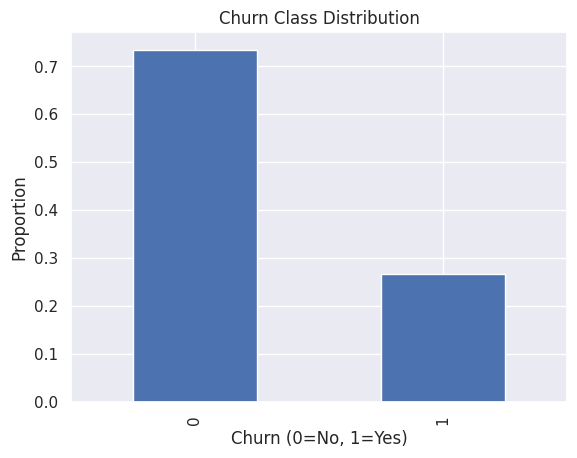

In [6]:
churn_rate = y.mean()
print("Churn rate:", churn_rate)

plt.figure()
y.value_counts(normalize=True).plot(kind='bar')
plt.title("Churn Class Distribution")
plt.xlabel("Churn (0=No, 1=Yes)")
plt.ylabel("Proportion")
plt.show()

### 4.1 Tenure vs Churn

We expect customers with shorter tenure to churn more often.

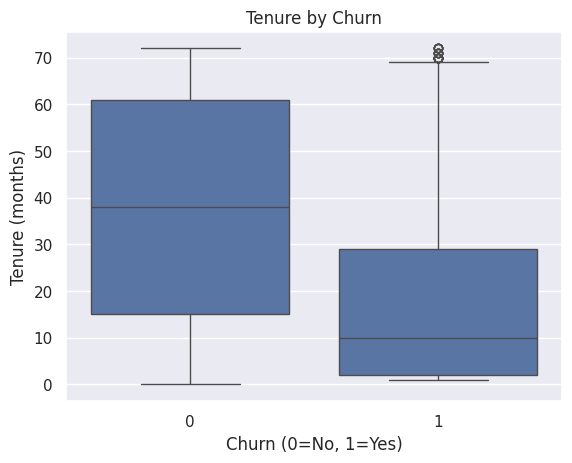

In [7]:
plt.figure()
sns.boxplot(x=df['Churn'], y=df['tenure'])
plt.title("Tenure by Churn")
plt.xlabel("Churn (0=No, 1=Yes)")
plt.ylabel("Tenure (months)")
plt.show()

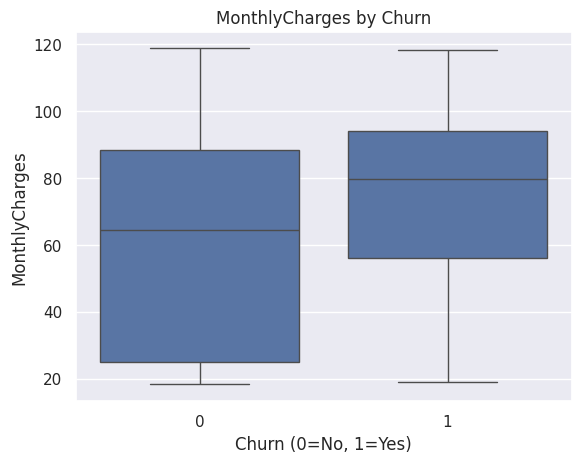

In [8]:
plt.figure()
sns.boxplot(x=df['Churn'], y=df['MonthlyCharges'])
plt.title("MonthlyCharges by Churn")
plt.xlabel("Churn (0=No, 1=Yes)")
plt.ylabel("MonthlyCharges")
plt.show()

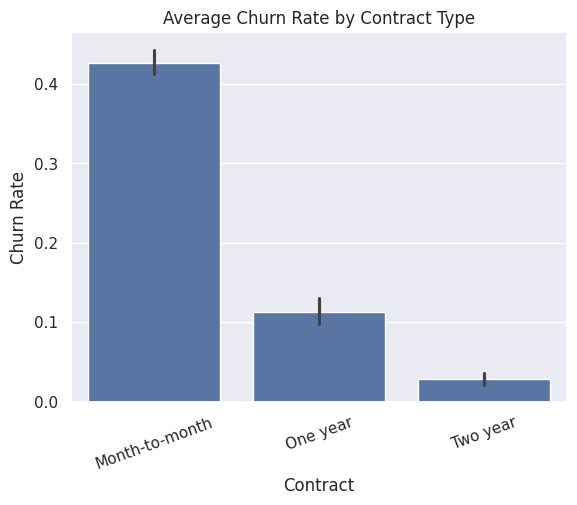

In [9]:
plt.figure()
sns.barplot(
    data=df,
    x='Contract',
    y='Churn',
    estimator=np.mean
)
plt.title("Average Churn Rate by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Churn Rate")
plt.xticks(rotation=20)
plt.show()

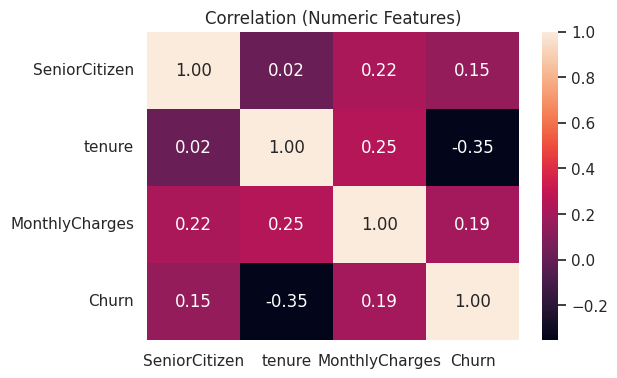

In [10]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
plt.figure(figsize=(6,4))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f")
plt.title("Correlation (Numeric Features)")
plt.show()

## 5. Baseline Models

We train three baseline models:
- Logistic Regression (interpretable baseline)
- Decision Tree (non-linear baseline)
- Random Forest (ensemble baseline)

We evaluate using Accuracy, Precision, Recall, F1, and ROC-AUC.

In [11]:
# Identify columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", "passthrough", cat_cols)  # We'll one-hot encode in next step using get_dummies approach OR use OneHotEncoder
    ],
    remainder="drop"
)

# Better: use OneHotEncoder directly (clean + reproducible)
from sklearn.preprocessing import OneHotEncoder

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:,1] if hasattr(pipe, "predict_proba") else None

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob) if prob is not None else np.nan
    }
    return pipe, metrics, prob

In [12]:
results = []
probs = {}
models = {}

pipe_lr, m_lr, prob_lr = evaluate_model(
    "Logistic Regression",
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    X_train, X_test, y_train, y_test
)
results.append(m_lr)
probs["Logistic Regression"] = prob_lr
models["Logistic Regression"] = pipe_lr

pipe_dt, m_dt, prob_dt = evaluate_model(
    "Decision Tree",
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    X_train, X_test, y_train, y_test
)
results.append(m_dt)
probs["Decision Tree"] = prob_dt
models["Decision Tree"] = pipe_dt

pipe_rf, m_rf, prob_rf = evaluate_model(
    "Random Forest",
    RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=300),
    X_train, X_test, y_train, y_test
)
results.append(m_rf)
probs["Random Forest"] = prob_rf
models["Random Forest"] = pipe_rf

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,Random Forest,0.799858,0.682540,0.459893,0.549521,0.833071
0,Logistic Regression,0.763662,0.730337,0.173797,0.280778,0.819486
1,Decision Tree,0.765791,0.565868,0.505348,0.533898,0.682625


### Baseline Model Performance Across Core Metrics

We evaluate the baseline models using four key classification metrics: Accuracy, Precision, Recall, and F1-score. These metrics provide a comprehensive understanding of model performance from different perspectives.

- **Accuracy** measures overall correctness.
- **Precision** reflects how many predicted positives are actually correct.
- **Recall** indicates how well the model captures true positive cases.
- **F1-score** balances precision and recall, making it especially useful for imbalanced datasets.

From the visual comparison, we observe that ensemble-based methods such as Random Forest generally perform more consistently across all metrics. Simpler models like Decision Tree may show weaker and less stable performance.

The highlighted bars indicate the best-performing model for each metric, allowing for quick identification of the strongest baseline approach.

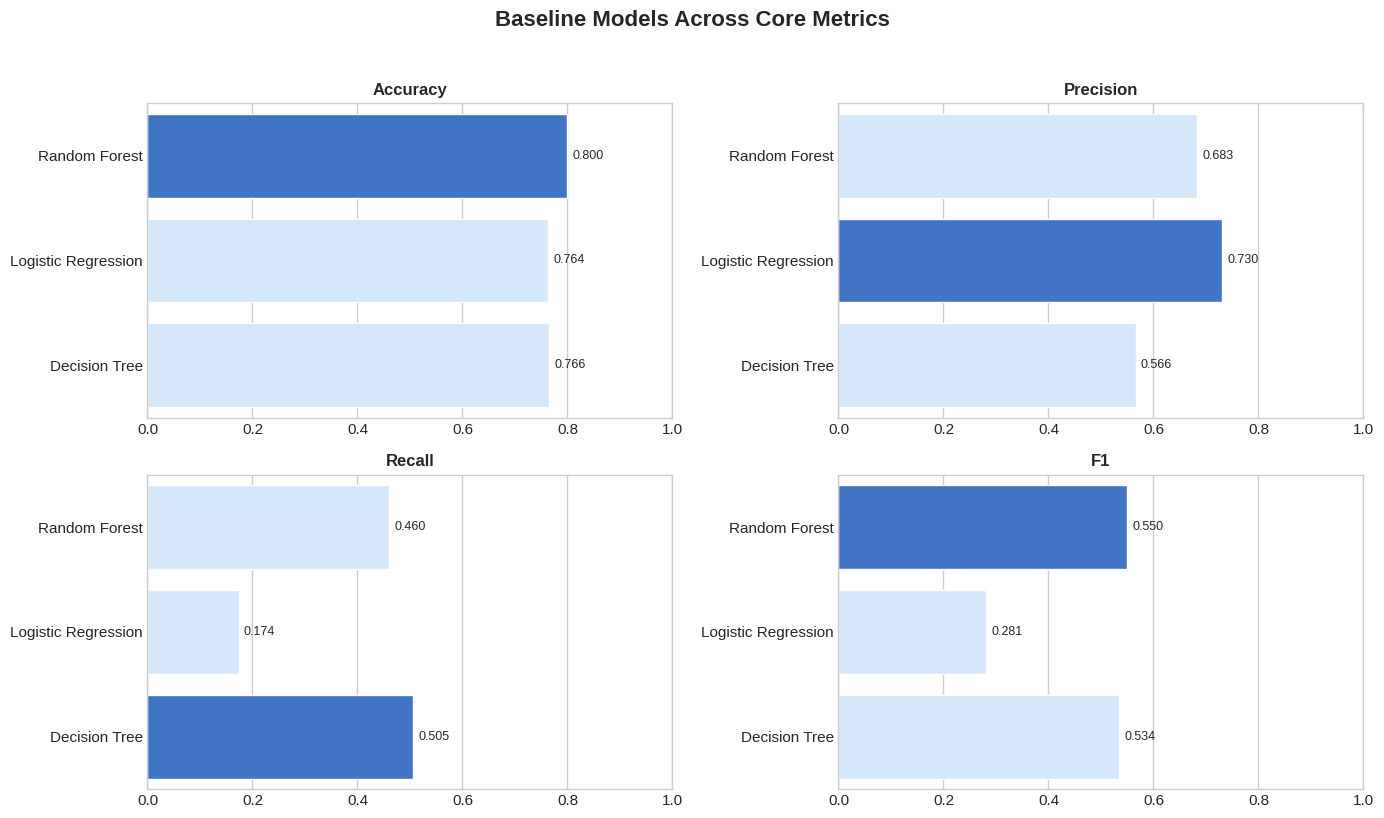

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")

metrics = ["Accuracy", "Precision", "Recall", "F1"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    best_idx = results_df[metric].idxmax()

    colors = ["#cfe8ff"] * len(results_df)
    colors[list(results_df.index).index(best_idx)] = "#2a6fdb"

    sns.barplot(
        data=results_df,
        x=metric,
        y="Model",
        hue="Model",
        palette=colors,
        legend=False,
        ax=axes[i]
    )

    axes[i].set_title(metric, fontsize=12, fontweight="bold")
    axes[i].set_xlim(0, 1)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

    for j, v in enumerate(results_df[metric]):
        axes[i].text(v + 0.01, j, f"{v:.3f}", va="center", fontsize=9)

plt.suptitle("Baseline Models Across Core Metrics", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### ROC-AUC Comparison

The ROC-AUC metric evaluates how well a model distinguishes between classes across different classification thresholds. It is particularly important for imbalanced datasets, as it measures ranking performance rather than relying on a fixed threshold.

The ROC-AUC bar chart provides a direct comparison of the models’ overall discriminative ability. Higher values indicate better performance, with a score of 0.5 representing random guessing.

In our baseline models, Random Forest achieves the highest ROC-AUC score, indicating superior ability to separate positive and negative classes. In contrast, the Decision Tree model shows comparatively lower performance.

The best-performing model is highlighted for clarity, making it easier to identify the most reliable baseline before proceeding to model improvements.

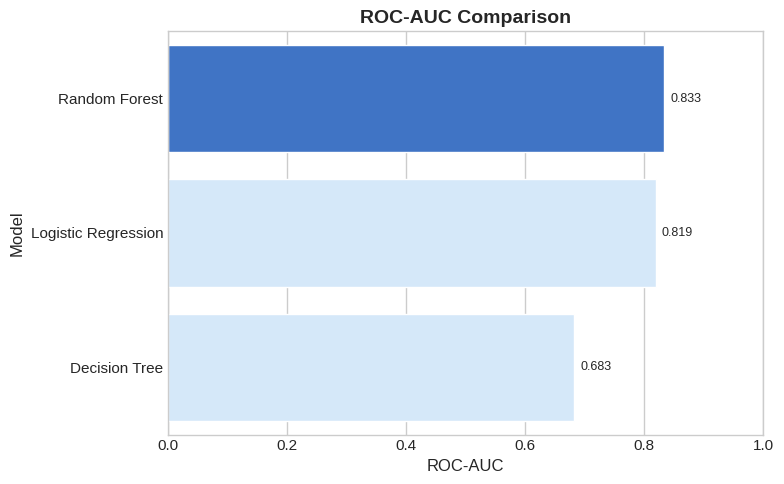

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")

# Ensure proper indexing
results_df = results_df.reset_index(drop=True)

# Find best model
best_idx = results_df["ROC-AUC"].idxmax()

# Colors
colors = ["#cfe8ff"] * len(results_df)
colors[best_idx] = "#2a6fdb"

plt.figure(figsize=(8, 5))

sns.barplot(
    data=results_df,
    x="ROC-AUC",
    y="Model",
    hue="Model",
    palette=colors,
    legend=False
)

plt.title("ROC-AUC Comparison", fontsize=14, fontweight="bold")
plt.xlim(0, 1)

for i, v in enumerate(results_df["ROC-AUC"]):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### ROC Curve Comparison

The ROC curve evaluates how well each baseline model distinguishes between classes.
The dashed diagonal line represents a random classifier.
Models closer to the top-left corner indicate better performance.

We highlight the best-performing model based on AUC.

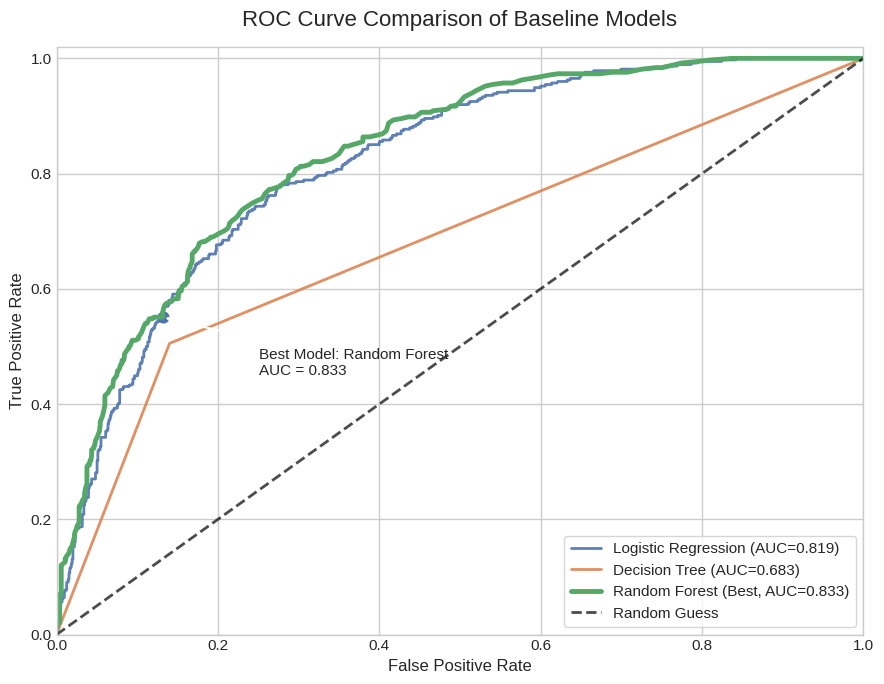

In [15]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(9, 7))

best_model = None
best_auc = -1
best_fpr = None
best_tpr = None

# Find best model
for model_name, prob in probs.items():
    if prob is not None:
        fpr, tpr, _ = roc_curve(y_test, prob)
        roc_auc = auc(fpr, tpr)
        if roc_auc > best_auc:
            best_auc = roc_auc
            best_model = model_name
            best_fpr = fpr
            best_tpr = tpr

# Plot all models
for model_name, prob in probs.items():
    if prob is not None:
        fpr, tpr, _ = roc_curve(y_test, prob)
        roc_auc = auc(fpr, tpr)

        if model_name == best_model:
            plt.plot(
                fpr, tpr,
                linewidth=3.5,
                label=f"{model_name} (Best, AUC={roc_auc:.3f})"
            )
        else:
            plt.plot(
                fpr, tpr,
                linewidth=2,
                alpha=0.9,
                label=f"{model_name} (AUC={roc_auc:.3f})"
            )

# Random baseline
plt.plot(
    [0, 1], [0, 1],
    linestyle="--",
    linewidth=2,
    color="black",
    alpha=0.7,
    label="Random Guess"
)

# Annotate best model near middle of its curve
mid_idx = len(best_fpr) // 2
plt.scatter(best_fpr[mid_idx], best_tpr[mid_idx], s=60)
plt.annotate(
    f"Best Model: {best_model}\nAUC = {best_auc:.3f}",
    xy=(best_fpr[mid_idx], best_tpr[mid_idx]),
    xytext=(best_fpr[mid_idx] + 0.12, best_tpr[mid_idx] - 0.1),
    arrowprops=dict(arrowstyle="->", lw=1.5),
    fontsize=11
)

plt.title("ROC Curve Comparison of Baseline Models", fontsize=16, pad=15)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc="lower right", frameon=True, fontsize=11)
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.tight_layout()
plt.show()

## 6. Improved Models

To enhance performance beyond the baseline models, we apply advanced modeling techniques and hyperparameter optimization.

### 1. Hyperparameter Tuning (Random Forest)

We optimize the Random Forest model using **RandomizedSearchCV**, which efficiently searches over a range of hyperparameters. Key parameters tuned include:
- Number of trees (`n_estimators`)
- Maximum depth (`max_depth`)
- Minimum samples for splits and leaves
- Feature selection strategy (`max_features`)
- Class weighting to handle imbalance

We use **Stratified K-Fold Cross-Validation** to preserve class distribution and ensure reliable evaluation. The model is optimized using **ROC-AUC**, a robust metric for classification performance.

---

### 2. Gradient Boosting

We introduce **Gradient Boosting**, a powerful ensemble method that builds models sequentially to correct previous errors. This approach often captures complex patterns better than individual models.

---

### 3. XGBoost (Optional)

If available, we also train an **XGBoost model**, an advanced gradient boosting implementation known for its efficiency and high performance in structured data problems.

### Tuned Logistic Regression

To further strengthen the benchmark comparison, we also tune Logistic Regression using RandomizedSearchCV. The search focuses on regularization strength, solver choice, and class weighting.

Although Logistic Regression is a simpler model than ensemble methods, tuning helps improve fairness in comparison and shows whether a linear model can remain competitive after optimization.

The tuned results are then compared with the baseline Logistic Regression using ROC-AUC.

In [16]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

# Safe Logistic Regression pipeline
lr_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

# Safer + better search space
param_dist_lr = {
    "model__C": loguniform(1e-3, 10),
    "model__solver": ["liblinear", "lbfgs"],
    "model__class_weight": [None, "balanced"]
}

# Cross-validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Randomized search
lr_search = RandomizedSearchCV(
    estimator=lr_pipeline,
    param_distributions=param_dist_lr,
    n_iter=8,               # smaller = safer
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

# Fit
lr_search.fit(X_train, y_train)

print("Best Logistic Regression params:", lr_search.best_params_)
print("Best CV ROC-AUC:", lr_search.best_score_)

# Evaluate on test set
best_lr = lr_search.best_estimator_
lr_prob_tuned = best_lr.predict_proba(X_test)[:, 1]
print("Tuned Logistic Regression Test ROC-AUC:", roc_auc_score(y_test, lr_prob_tuned))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Logistic Regression params: {'model__C': np.float64(0.0012087541473056963), 'model__class_weight': 'balanced', 'model__solver': 'lbfgs'}
Best CV ROC-AUC: 0.8281203216283498
Tuned Logistic Regression Test ROC-AUC: 0.8215996279934898


In [17]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

# Pipeline
rf_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1   # faster training
    ))
])

# Parameter distributions (fast + reasonable search space)
param_dist = {
    "model__n_estimators": randint(150, 400),   # comma was missing
    "model__max_depth": [10, 15, 20, 25],
    "model__min_samples_split": randint(2, 10),
    "model__min_samples_leaf": randint(1, 5),
    "model__max_features": ["sqrt", "log2", None],
    "model__class_weight": ["balanced"]
}

# Faster CV
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Randomized Search
search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=15,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

# Fit
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV ROC-AUC:", search.best_score_)

# Evaluate on test set
best_rf = search.best_estimator_
rf_prob = best_rf.predict_proba(X_test)[:, 1]
print("Tuned RF Test ROC-AUC:", roc_auc_score(y_test, rf_prob))

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params: {'model__class_weight': 'balanced', 'model__max_depth': 15, 'model__max_features': None, 'model__min_samples_leaf': 4, 'model__min_samples_split': 8, 'model__n_estimators': 393}
Best CV ROC-AUC: 0.8347359984999949
Tuned RF Test ROC-AUC: 0.8354801209021159


In [18]:
gb_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

gb_pipeline.fit(X_train, y_train)
gb_prob = gb_pipeline.predict_proba(X_test)[:,1]
print("Gradient Boosting Test ROC-AUC:", roc_auc_score(y_test, gb_prob))

Gradient Boosting Test ROC-AUC: 0.8453072928776254


In [19]:
if XGBOOST_AVAILABLE:
    xgb_pipeline = Pipeline([
        ("preprocess", preprocess),
        ("model", XGBClassifier(
            random_state=RANDOM_STATE,
            n_estimators=600,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss"
        ))
    ])
    xgb_pipeline.fit(X_train, y_train)
    xgb_prob = xgb_pipeline.predict_proba(X_test)[:,1]
    print("XGBoost Test ROC-AUC:", roc_auc_score(y_test, xgb_prob))
else:
    print("XGBoost not available in this environment.")

XGBoost Test ROC-AUC: 0.8331305381177505


In [20]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from scipy.stats import randint, uniform

# Pipeline
gb_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

# Search space
param_dist_gb = {
    "model__n_estimators": randint(100, 300),
    "model__learning_rate": uniform(0.03, 0.12),   # roughly 0.03 to 0.15
    "model__max_depth": randint(2, 5),
    "model__min_samples_split": randint(2, 10),
    "model__min_samples_leaf": randint(1, 5),
    "model__subsample": uniform(0.7, 0.3)          # roughly 0.7 to 1.0
}

# CV
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Randomized search
gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=param_dist_gb,
    n_iter=10,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

# Fit
gb_search.fit(X_train, y_train)

print("Best Gradient Boosting params:", gb_search.best_params_)
print("Best CV ROC-AUC:", gb_search.best_score_)

# Test evaluation
best_gb = gb_search.best_estimator_
gb_prob_tuned = best_gb.predict_proba(X_test)[:, 1]
print("Tuned Gradient Boosting Test ROC-AUC:", roc_auc_score(y_test, gb_prob_tuned))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Gradient Boosting params: {'model__learning_rate': np.float64(0.07624998030478994), 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 3, 'model__n_estimators': 183, 'model__subsample': np.float64(0.7723076398078035)}
Best CV ROC-AUC: 0.8486568319481363
Tuned Gradient Boosting Test ROC-AUC: 0.8462011418533157


## 6.1 ROC Curve Comparison of Tuned Models

In this section, we evaluate and compare the performance of all optimized models using the **Receiver Operating Characteristic (ROC) curve**.

The ROC curve visualizes the trade-off between:
- **True Positive Rate (Recall)**
- **False Positive Rate**

###  Why ROC-AUC?
- It provides a **threshold-independent** performance metric  
- Works well even with **imbalanced datasets**  
- A higher **AUC (Area Under Curve)** indicates better model performance  

###  What This Plot Shows
- Each curve represents a different tuned model  
- Curves closer to the **top-left corner** indicate better performance  
- The dashed diagonal line represents a **random classifier baseline**  

###  Models Compared
- Tuned Logistic Regression  
- Tuned Random Forest  
- Tuned Gradient Boosting  
- XGBoost *(if available)*  

 **Key Insight:**  
The model with the highest ROC-AUC score has the strongest ability to distinguish between classes and is typically the best candidate for deployment.

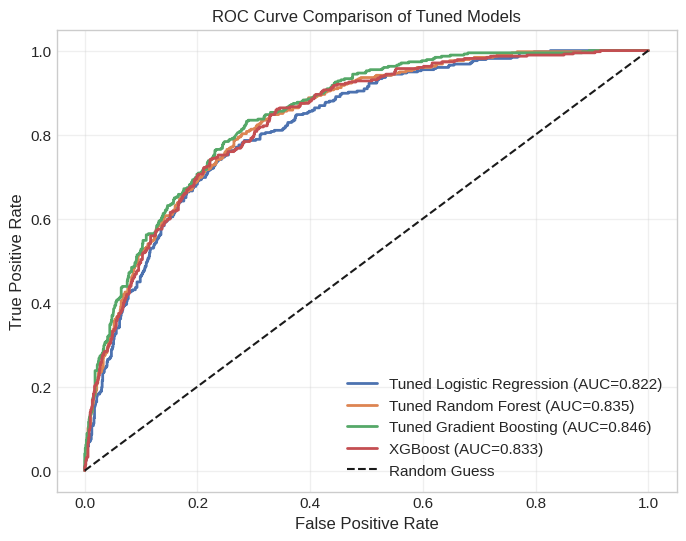

In [21]:
# =========================
# ROC Curve Comparison
# =========================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))

# Tuned Logistic Regression
fpr, tpr, _ = roc_curve(y_test, lr_prob_tuned)
plt.plot(
    fpr, tpr,
    linewidth=2,
    label=f"Tuned Logistic Regression (AUC={roc_auc_score(y_test, lr_prob_tuned):.3f})"
)

# Tuned Random Forest
fpr, tpr, _ = roc_curve(y_test, rf_prob)
plt.plot(
    fpr, tpr,
    linewidth=2,
    label=f"Tuned Random Forest (AUC={roc_auc_score(y_test, rf_prob):.3f})"
)

# Tuned Gradient Boosting
fpr, tpr, _ = roc_curve(y_test, gb_prob_tuned)
plt.plot(
    fpr, tpr,
    linewidth=2,
    label=f"Tuned Gradient Boosting (AUC={roc_auc_score(y_test, gb_prob_tuned):.3f})"
)

# XGBoost
if XGBOOST_AVAILABLE:
    fpr, tpr, _ = roc_curve(y_test, xgb_prob)
    plt.plot(
        fpr, tpr,
        linewidth=2,
        label=f"XGBoost (AUC={roc_auc_score(y_test, xgb_prob):.3f})"
    )

# Random guess line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Tuned Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## 7. Improved Model Evaluation

Now that we have trained and tuned our improved models, we evaluate them using the same metrics as the baseline:
Accuracy, Precision, Recall, F1, and ROC-AUC.

This allows for a fair and consistent comparison across all models.

- **Tuned Logistic Regression** — regularization and solver optimized via RandomizedSearchCV
- **Tuned Random Forest** — tree depth, estimators, and class weight optimized
- **Tuned Gradient Boosting** — learning rate, depth, and subsampling optimized
- **XGBoost** — advanced boosting with column and row subsampling *(if available)*

In [22]:
# =============================================
# Collect Improved Model Metrics
# =============================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

improved_results = []

# Tuned Logistic Regression
pred_lr = best_lr.predict(X_test)
improved_results.append({
    "Model": "Tuned Logistic Regression",
    "Accuracy": accuracy_score(y_test, pred_lr),
    "Precision": precision_score(y_test, pred_lr),
    "Recall": recall_score(y_test, pred_lr),
    "F1": f1_score(y_test, pred_lr),
    "ROC-AUC": roc_auc_score(y_test, lr_prob_tuned)
})

# Tuned Random Forest
pred_rf = best_rf.predict(X_test)
improved_results.append({
    "Model": "Tuned Random Forest",
    "Accuracy": accuracy_score(y_test, pred_rf),
    "Precision": precision_score(y_test, pred_rf),
    "Recall": recall_score(y_test, pred_rf),
    "F1": f1_score(y_test, pred_rf),
    "ROC-AUC": roc_auc_score(y_test, rf_prob)
})

# Tuned Gradient Boosting
pred_gb = best_gb.predict(X_test)
improved_results.append({
    "Model": "Tuned Gradient Boosting",
    "Accuracy": accuracy_score(y_test, pred_gb),
    "Precision": precision_score(y_test, pred_gb),
    "Recall": recall_score(y_test, pred_gb),
    "F1": f1_score(y_test, pred_gb),
    "ROC-AUC": roc_auc_score(y_test, gb_prob_tuned)
})

# XGBoost (if available)
if XGBOOST_AVAILABLE:
    pred_xgb = xgb_pipeline.predict(X_test)
    improved_results.append({
        "Model": "XGBoost",
        "Accuracy": accuracy_score(y_test, pred_xgb),
        "Precision": precision_score(y_test, pred_xgb),
        "Recall": recall_score(y_test, pred_xgb),
        "F1": f1_score(y_test, pred_xgb),
        "ROC-AUC": roc_auc_score(y_test, xgb_prob)
    })

improved_df = pd.DataFrame(improved_results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
improved_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Tuned Gradient Boosting,0.801278,0.660959,0.516043,0.579580,0.846201
1,Tuned Random Forest,0.772179,0.559020,0.671123,0.609964,0.835480
2,XGBoost,0.793471,0.635179,0.521390,0.572687,0.833131
3,Tuned Logistic Regression,0.784244,0.675000,0.360963,0.470383,0.821600


### 7.1 Improved Models — Core Metrics Bar Chart

We visualize the performance of all tuned models across four key metrics: Accuracy, Precision, Recall, and F1-score.

The **green bar** highlights the best-performing model for each metric.

Compared to the baseline chart, these models generally show stronger and more balanced performance,
particularly in Recall and F1 — metrics that matter most for identifying churners in an imbalanced dataset.

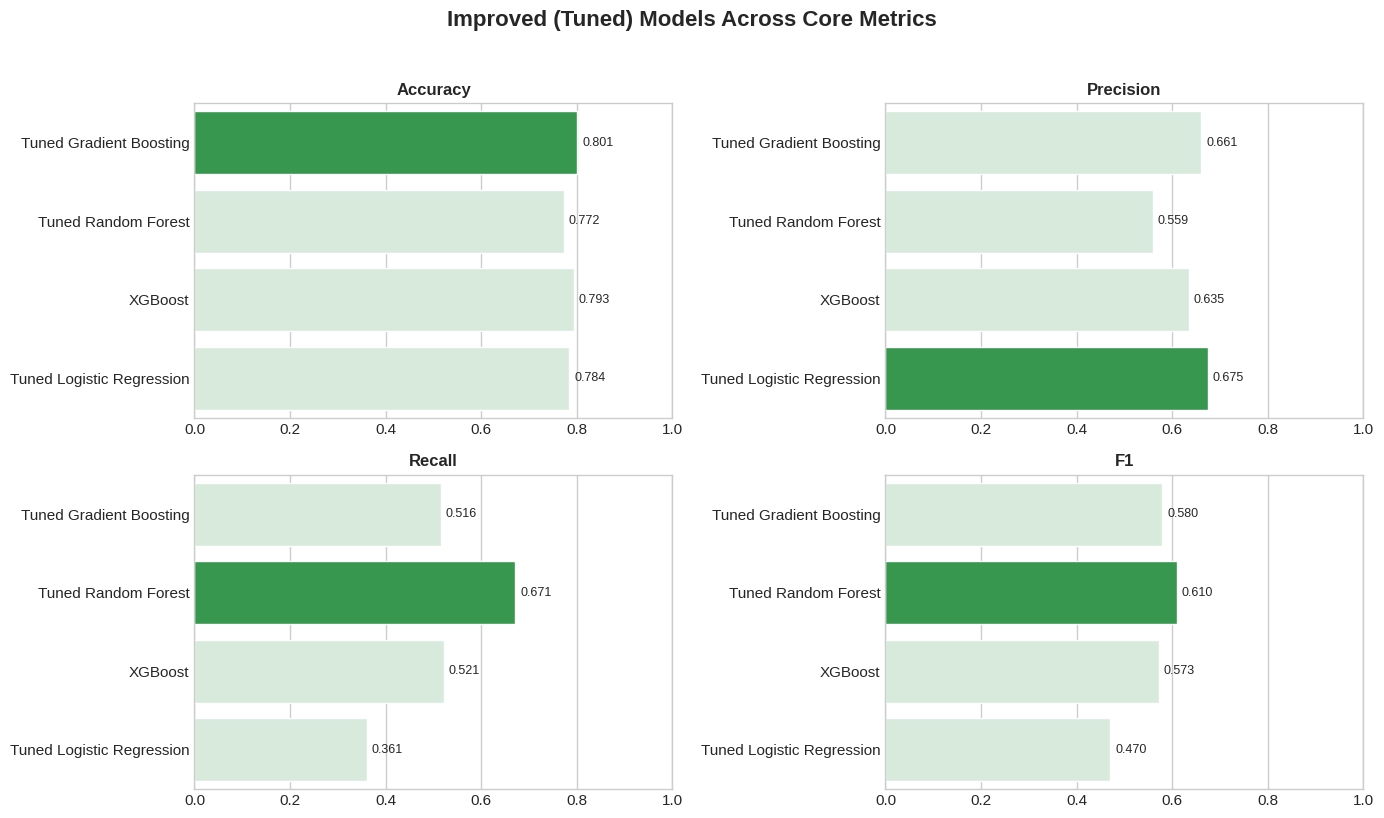

In [23]:
# =============================================
# Bar Graph: Improved Models Across Core Metrics
# =============================================
plt.style.use("seaborn-v0_8-whitegrid")

metrics = ["Accuracy", "Precision", "Recall", "F1"]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    best_idx = improved_df[metric].idxmax()
    colors = ["#d4edda"] * len(improved_df)
    colors[best_idx] = "#28a745"   # green highlight for best

    sns.barplot(
        data=improved_df,
        x=metric,
        y="Model",
        hue="Model",
        palette=colors,
        legend=False,
        ax=axes[i]
    )
    axes[i].set_title(metric, fontsize=12, fontweight="bold")
    axes[i].set_xlim(0, 1)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

    for j, v in enumerate(improved_df[metric]):
        axes[i].text(v + 0.01, j, f"{v:.3f}", va="center", fontsize=9)

plt.suptitle("Improved (Tuned) Models Across Core Metrics", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 7.2 Improved Models — ROC-AUC Comparison

The ROC-AUC bar chart gives a single-number summary of each tuned model's discriminative ability.

A higher ROC-AUC means the model is better at ranking churners above non-churners across all thresholds.
The best-performing improved model is highlighted in green for quick identification.

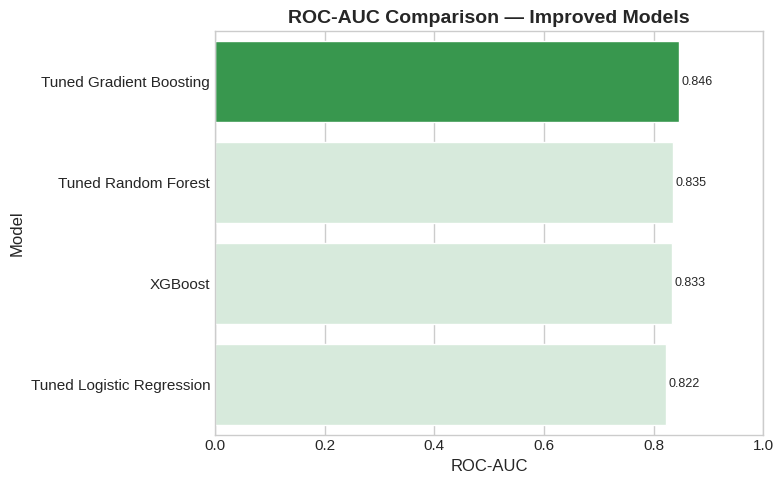

In [24]:
# =============================================
# ROC-AUC Bar Chart: Improved Models
# =============================================
best_idx = improved_df["ROC-AUC"].idxmax()
colors = ["#d4edda"] * len(improved_df)
colors[best_idx] = "#28a745"

plt.figure(figsize=(8, 5))
sns.barplot(
    data=improved_df,
    x="ROC-AUC",
    y="Model",
    hue="Model",
    palette=colors,
    legend=False
)
plt.title("ROC-AUC Comparison — Improved Models", fontsize=14, fontweight="bold")
plt.xlim(0, 1)
for i, v in enumerate(improved_df["ROC-AUC"]):
    plt.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 8. Baseline vs Improved Models — Comparison

In this section, we directly compare the baseline models and the improved (tuned) models
across all five evaluation metrics.

This comparison helps us quantify the benefit of hyperparameter tuning and advanced ensemble methods.

- **Blue bars** represent the average performance of baseline models
- **Green bars** represent the average performance of improved models

A consistent improvement across all metrics confirms that tuning was effective.

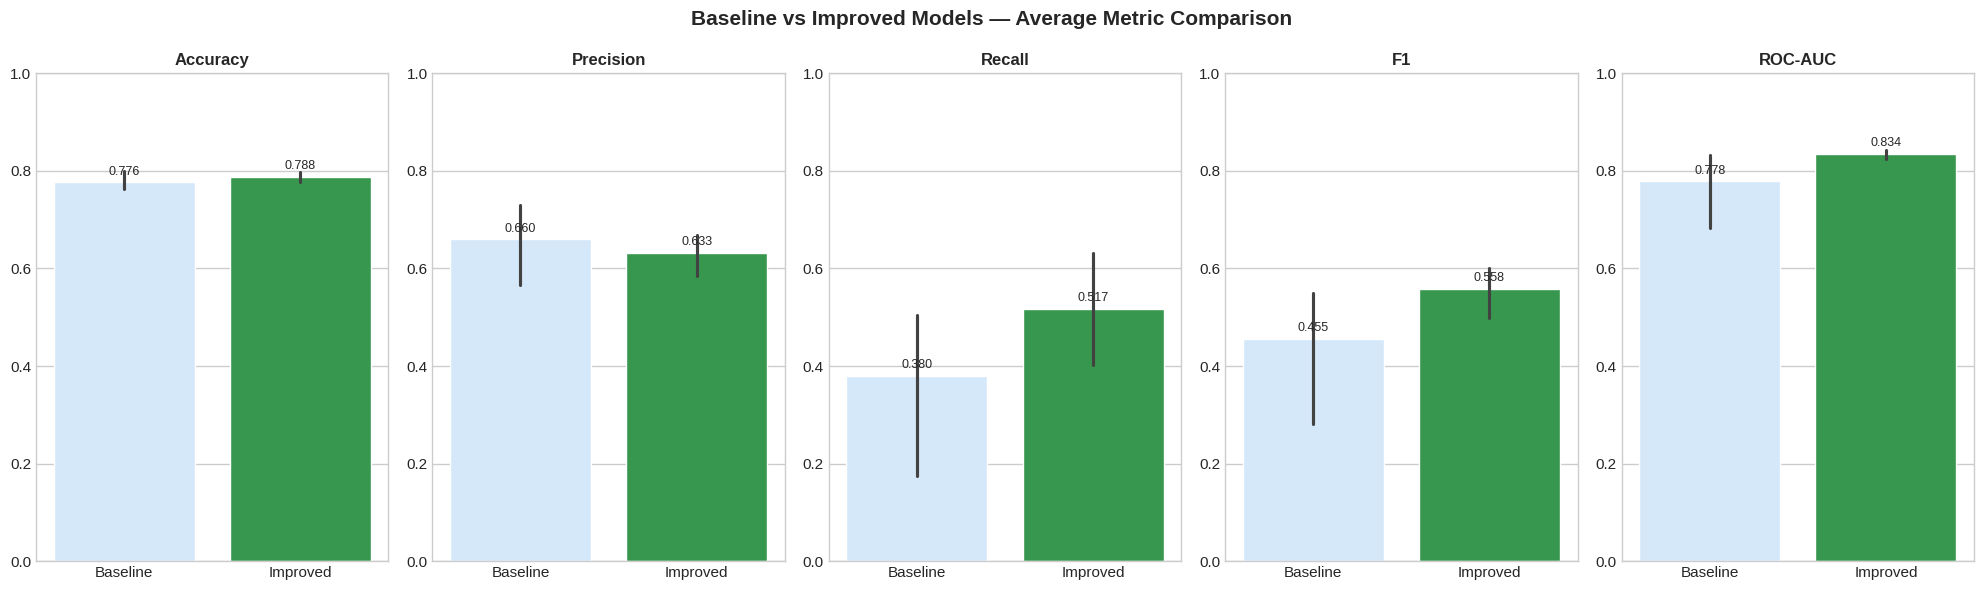

In [25]:
# =============================================
# Comparison: Baseline vs Improved Models
# =============================================

# Label the groups
baseline_labeled = results_df[["Model","Accuracy","Precision","Recall","F1","ROC-AUC"]].copy()
baseline_labeled["Group"] = "Baseline"

improved_labeled = improved_df[["Model","Accuracy","Precision","Recall","F1","ROC-AUC"]].copy()
improved_labeled["Group"] = "Improved"

comparison_df = pd.concat([baseline_labeled, improved_labeled], ignore_index=True)

# Plot each metric side by side
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
fig, axes = plt.subplots(1, len(metrics), figsize=(20, 6))

for i, metric in enumerate(metrics):
    sns.barplot(
        data=comparison_df,
        x="Group",
        y=metric,
        hue="Group",
        palette={"Baseline": "#cfe8ff", "Improved": "#28a745"},
        legend=False,
        ax=axes[i]
    )
    axes[i].set_title(metric, fontsize=12, fontweight="bold")
    axes[i].set_ylim(0, 1)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

    # Add value labels
    for bar in axes[i].patches:
        h = bar.get_height()
        if h > 0:
            axes[i].text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.01, f"{h:.3f}",
                ha="center", va="bottom", fontsize=9
            )

plt.suptitle("Baseline vs Improved Models — Average Metric Comparison", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### 8.1 Best Model Summary — Baseline vs Improved

To summarize our findings, we select the single best-performing model from each group
(based on ROC-AUC) and compare them head-to-head across all metrics.

The delta row shows the exact numerical improvement gained by moving from the best baseline
to the best improved model — giving a concrete measure of how much tuning helped.
```

**Then paste → Cell 5 code** (Summary table + delta)

---

### Final notebook structure will look like this:
```
Cell 0–14   →  Introduction, Dataset, EDA
Cell 15–23  →  Section 5: Baseline Models
Cell 24–32  →  Section 6: Improved Models (training)
Cell 33     →  ROC Curve of Tuned Models  ← your last existing cell

── NEW CELLS ──
Markdown    →  ## 7. Improved Model Evaluation
Code        →  Collect improved model metrics
Markdown    →  ### 7.1 Core Metrics Bar Chart
Code        →  Bar graph of improved models
Markdown    →  ### 7.2 ROC-AUC Comparison
Code        →  ROC-AUC bar for improved models
Markdown    →  ## 8. Baseline vs Improved Comparison
Code        →  Side-by-side comparison chart
Markdown    →  ### 8.1 Best Model Summary
Code        →  Summary table + delta

In [26]:
# =============================================
# Summary Table: Best Baseline vs Best Improved
# =============================================

best_baseline = results_df.loc[results_df["ROC-AUC"].idxmax()].copy()
best_improved = improved_df.loc[improved_df["ROC-AUC"].idxmax()].copy()

summary = pd.DataFrame([best_baseline, best_improved]).set_index("Model")
summary = summary[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]]
print("=== Best Baseline vs Best Improved ===")
print(summary.to_string())

# Delta row
delta = summary.iloc[1] - summary.iloc[0]
print("\n=== Improvement (Improved - Baseline) ===")
print(delta.to_string())

=== Best Baseline vs Best Improved ===
                         Accuracy  Precision    Recall        F1   ROC-AUC
Model                                                                     
Random Forest            0.799858   0.682540  0.459893  0.549521  0.833071
Tuned Gradient Boosting  0.801278   0.660959  0.516043  0.579580  0.846201

=== Improvement (Improved - Baseline) ===
Accuracy     0.001419
Precision   -0.021581
Recall       0.056150
F1           0.030059
ROC-AUC      0.013130


## 9. Confusion Matrix — Best Improved Model

A confusion matrix breaks down the model's predictions into four categories:

| | Predicted No Churn | Predicted Churn |
|---|---|---|
| **Actual No Churn** | True Negative (TN) | False Positive (FP) |
| **Actual Churn** | False Negative (FN) | True Positive (TP) |

For churn prediction, **False Negatives are the most costly** — these are real churners
the model missed, meaning the business loses customers it could have retained.

We display the confusion matrix for the best improved model (highest ROC-AUC).

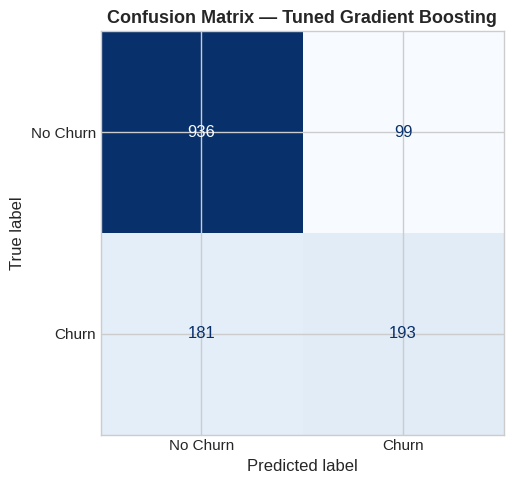

True Negatives  (Correct No Churn): 936
False Positives (Wrong Churn Alert): 99
False Negatives (Missed Churners):   181  ← most costly
True Positives  (Caught Churners):   193


In [27]:
# =============================================
# Confusion Matrix — Best Improved Model
# =============================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Identify best improved model dynamically
best_row = improved_df.loc[improved_df["ROC-AUC"].idxmax()]
best_model_name = best_row["Model"]

# Map name to predictions
pred_map = {
    "Tuned Logistic Regression": best_lr.predict(X_test),
    "Tuned Random Forest":       best_rf.predict(X_test),
    "Tuned Gradient Boosting":   best_gb.predict(X_test),
}
if XGBOOST_AVAILABLE:
    pred_map["XGBoost"] = xgb_pipeline.predict(X_test)

best_preds = pred_map[best_model_name]

# Plot
cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix — {best_model_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Print breakdown
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Correct No Churn): {tn}")
print(f"False Positives (Wrong Churn Alert): {fp}")
print(f"False Negatives (Missed Churners):   {fn}  ← most costly")
print(f"True Positives  (Caught Churners):   {tp}")

## 10. Feature Importance — What Drives Churn?

Feature importance tells us which customer attributes most strongly influence
the model's churn predictions.

We extract importance scores from the best tree-based improved model
(Tuned Random Forest or Tuned Gradient Boosting).

Higher importance = stronger influence on whether a customer churns.

This is valuable for the business — it shows **which factors to act on**
to reduce churn (e.g., contract type, tenure, monthly charges).

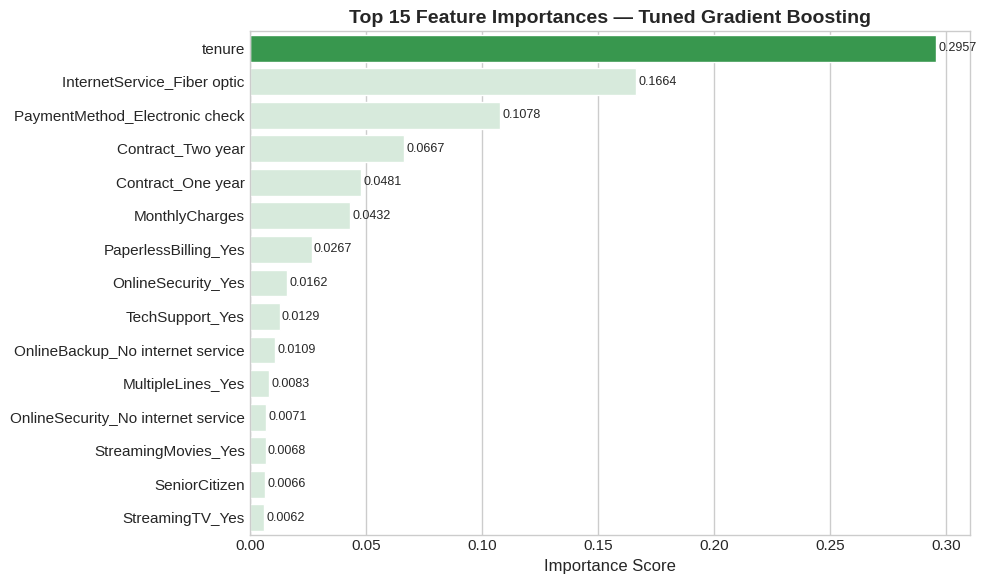

In [28]:
# =============================================
# Feature Importance — Best Tree-Based Model
# =============================================

# Pick best tree-based model
if best_model_name in ["Tuned Random Forest", "Tuned Gradient Boosting"]:
    fi_model = best_rf if best_model_name == "Tuned Random Forest" else best_gb
else:
    # Fall back to Tuned Random Forest if best is LR or XGBoost
    fi_model = best_rf
    print("Note: Feature importance shown for Tuned Random Forest")

# Extract feature names after preprocessing
try:
    feature_names = fi_model.named_steps["preprocess"].get_feature_names_out()
except AttributeError:
    feature_names = [f"Feature {i}" for i in range(len(fi_model.named_steps["model"].feature_importances_))]

importances = fi_model.named_steps["model"].feature_importances_

# Build and sort DataFrame
fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False).head(15).reset_index(drop=True)

# Clean up feature name prefixes (num__ / cat__)
fi_df["Feature"] = fi_df["Feature"].str.replace(r"^(num__|cat__)", "", regex=True)

# Plot
plt.figure(figsize=(10, 6))
colors = ["#28a745" if i == 0 else "#d4edda" for i in range(len(fi_df))]
sns.barplot(data=fi_df, x="Importance", y="Feature", palette=colors, hue="Feature", legend=False)
plt.title(f"Top 15 Feature Importances — {best_model_name}", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score")
plt.ylabel("")
for i, v in enumerate(fi_df["Importance"]):
    plt.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 11. Precision-Recall Curve

For imbalanced datasets like churn prediction (where churners are the minority class),
the **Precision-Recall curve is often more informative than the ROC curve**.

- **Precision** — of all customers flagged as churners, how many actually churn?
- **Recall** — of all actual churners, how many did we catch?

The **Average Precision (AP)** score summarizes the curve. Higher is better.

A model that achieves high precision *and* high recall is ideal — it catches
churners without flooding the retention team with false alerts.

We compare all improved models on this curve.

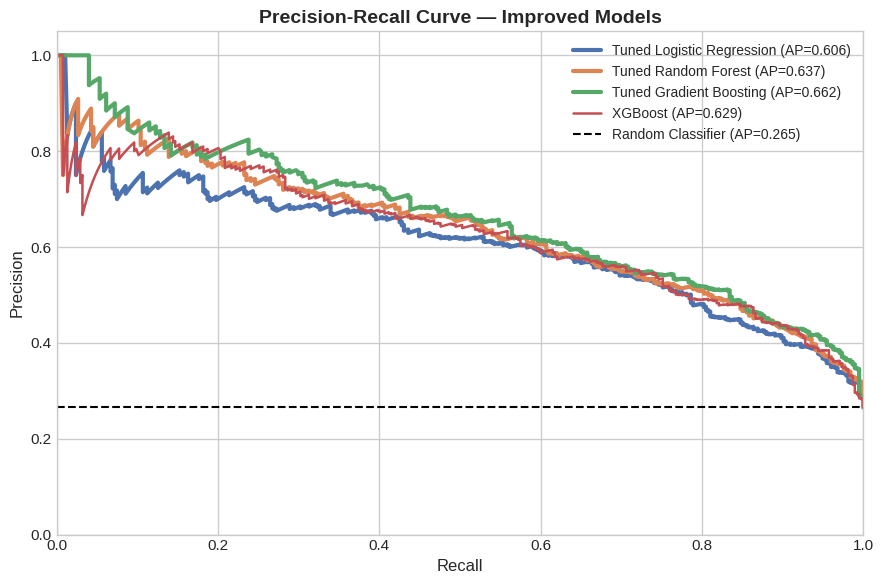

Best model by Average Precision: Tuned Gradient Boosting (AP=0.662)


In [29]:
# =============================================
# Precision-Recall Curve — All Improved Models
# =============================================
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(9, 6))
plt.style.use("seaborn-v0_8-whitegrid")

prob_map = {
    "Tuned Logistic Regression": lr_prob_tuned,
    "Tuned Random Forest":       rf_prob,
    "Tuned Gradient Boosting":   gb_prob_tuned,
}
if XGBOOST_AVAILABLE:
    prob_map["XGBoost"] = xgb_prob

best_ap = -1
best_pr_name = ""

for model_name, prob in prob_map.items():
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    
    is_best = ap > best_ap
    if is_best:
        best_ap = ap
        best_pr_name = model_name

    plt.plot(
        recall, precision,
        linewidth=3 if is_best else 1.8,
        label=f"{model_name} (AP={ap:.3f})"
    )

# Baseline: random classifier AP = churn rate
baseline_ap = y_test.mean()
plt.axhline(y=baseline_ap, color="black", linestyle="--", linewidth=1.5,
            label=f"Random Classifier (AP={baseline_ap:.3f})")

plt.title("Precision-Recall Curve — Improved Models", fontsize=14, fontweight="bold")
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.legend(loc="upper right", fontsize=10)
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

print(f"Best model by Average Precision: {best_pr_name} (AP={best_ap:.3f})")

## 12. Learning Curve — Does the Best Model Need More Data?

A learning curve shows how model performance changes as we increase the training data size.

- If **training score >> validation score** → the model is **overfitting** (needs more data or regularization)
- If **both scores are low and plateau** → the model is **underfitting** (needs a more complex model)
- If **both scores converge and are high** → the model is well-fitted ✅

We plot the learning curve for the best improved model using ROC-AUC as the metric.
This tells us whether collecting more customer data would further improve predictions.

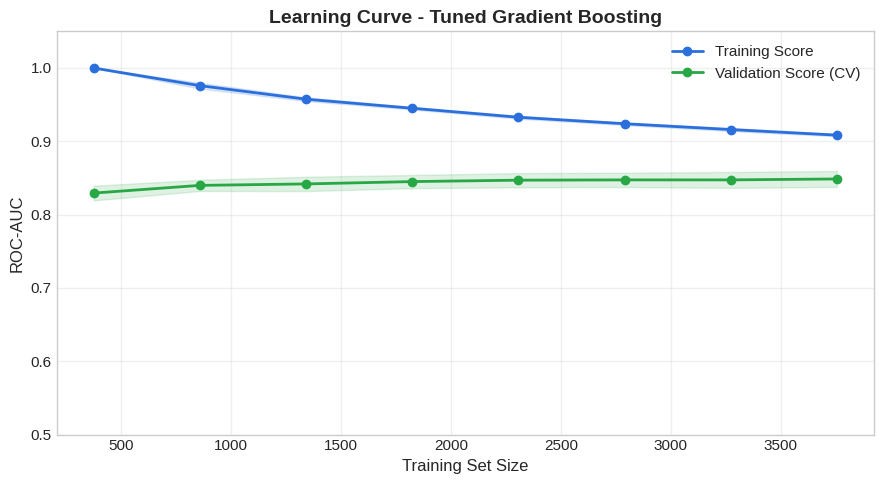

Final Training ROC-AUC:   0.908
Final Validation ROC-AUC: 0.849
Gap: 0.060
Some overfitting detected. Consider more regularization or data.


In [30]:
# =============================================
# Learning Curve - Best Improved Model
# =============================================
from sklearn.model_selection import learning_curve

model_map = {
    "Tuned Logistic Regression": best_lr,
    "Tuned Random Forest":       best_rf,
    "Tuned Gradient Boosting":   best_gb,
}
if XGBOOST_AVAILABLE:
    model_map["XGBoost"] = xgb_pipeline

lc_model = model_map[best_model_name]

train_sizes, train_scores, val_scores = learning_curve(
    lc_model,
    X_train, y_train,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, "o-", color="#2a6fdb", linewidth=2, label="Training Score")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="#2a6fdb")
plt.plot(train_sizes, val_mean, "o-", color="#28a745", linewidth=2, label="Validation Score (CV)")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color="#28a745")

plt.title("Learning Curve - " + best_model_name, fontsize=14, fontweight="bold")
plt.xlabel("Training Set Size", fontsize=12)
plt.ylabel("ROC-AUC", fontsize=12)
plt.legend(fontsize=11)
plt.ylim(0.5, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

gap = train_mean[-1] - val_mean[-1]
print(f"Final Training ROC-AUC:   {train_mean[-1]:.3f}")
print(f"Final Validation ROC-AUC: {val_mean[-1]:.3f}")
print(f"Gap: {gap:.3f}")
if gap > 0.05:
    print("Some overfitting detected. Consider more regularization or data.")
else:
    print("Model generalizes well!")